# 데이터 전처리

In [1]:
import os
import sys
import math
import copy
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Layer, InputSpec, Dense, Dropout, Activation, Flatten, Input
)
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from tensorflow.keras import (
    initializers, regularizers, constraints, backend as K
)
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, History
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 재귀 제한 설정 (필요한 경우만 사용)
sys.setrecursionlimit(10000)


import matplotlib.pyplot as plt

In [2]:
import pandas as pd
pd.set_option('display.max_column',None)

for i in range(1,25+1):
  globals()["exp_{:02d}_df".format(i)] = pd.read_csv(r"/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_{:02d}.csv".format(i))

train_df = pd.read_csv("/Users/leehyunsong/Desktop/심화프로젝트/dataset/train.csv", header = 0, encoding = 'utf-8')

In [3]:
# 공정이 끝까지 안돌아간 경우 
machine_no_list = list(train_df[train_df['machining_finalized']=='no']['No'].values)

machine_no_df_list = []
for i in machine_no_list:
  machine_no_df_list.append(globals()["exp_{:02d}_df".format(i)])

machine_no_df = pd.concat(machine_no_df_list,axis=0)

machine_no_df

,X_ActualPosition,X_ActualVelocity,X_ActualAcceleration,X_SetPosition,X_SetVelocity,X_SetAcceleration,X_CurrentFeedback,X_DCBusVoltage,X_OutputCurrent,X_OutputVoltage,X_OutputPower,Y_ActualPosition,Y_ActualVelocity,Y_ActualAcceleration,Y_SetPosition,Y_SetVelocity,Y_SetAcceleration,Y_CurrentFeedback,Y_DCBusVoltage,Y_OutputCurrent,Y_OutputVoltage,Y_OutputPower,Z_ActualPosition,Z_ActualVelocity,Z_ActualAcceleration,Z_SetPosition,Z_SetVelocity,Z_SetAcceleration,Z_CurrentFeedback,Z_DCBusVoltage,Z_OutputCurrent,Z_OutputVoltage,S_ActualPosition,S_ActualVelocity,S_ActualAcceleration,S_SetPosition,S_SetVelocity,S_SetAcceleration,S_CurrentFeedback,S_DCBusVoltage,S_OutputCurrent,S_OutputVoltage,S_OutputPower,S_SystemInertia,M_CURRENT_PROGRAM_NUMBER,M_sequence_number,M_CURRENT_FEEDRATE,Machining_Process
0,202.0,4.025,10.250,202.0,4.00,4.00,-1.420,0.0219,328,0.557,-0.000002,162.00,4.0000,4.000,162.00,4.00,4.0,0.0598,0.0152,327,1.390,0.000000e+00,123.00,4.0000,4.000,123.0,4.0,4.0,0,0,0,0,343.0,3.999000,3.750,343.0,4.00,4.0,0.0666,2.750000e-19,328,0.0,-9.930000e-07,16,1,2,50,Prep
1,202.0,4.000,4.000,202.0,4.00,4.00,-1.900,0.0206,329,1.920,0.000000,162.00,4.0250,16.500,162.00,4.00,4.0,-0.0998,0.0141,327,1.550,2.530000e-06,123.00,4.0000,4.000,123.0,4.0,4.0,0,0,0,0,343.0,4.000750,4.375,343.0,4.00,4.0,0.0540,2.750000e-19,328,0.0,7.290000e-07,16,1,0,50,Prep
2,202.0,4.000,4.000,202.0,4.00,4.00,-2.060,0.0237,329,1.810,0.000002,162.00,4.0250,16.500,162.00,4.00,4.0,-0.8990,0.0174,327,2.610,0.000000e+00,123.00,4.0000,4.000,123.0,4.0,4.0,0,0,0,0,343.0,3.998250,3.375,343.0,4.00,4.0,0.1570,2.750000e-19,329,0.0,0.000000e+00,16,1,0,50,Prep
3,202.0,4.025,10.250,202.0,4.00,4.00,-2.220,0.0225,329,1.870,-0.000005,162.00,4.0250,16.500,162.00,4.00,4.0,0.0598,0.0167,327,1.240,4.800000e-07,123.00,4.0000,4.000,123.0,4.0,4.0,0,0,0,0,343.0,4.000000,4.000,343.0,4.00,4.0,0.0791,2.750000e-19,329,0.0,0.000000e+00,16,1,0,50,Prep
4,202.0,3.975,-2.250,202.0,4.00,4.00,0.499,0.0260,329,1.790,0.000002,162.00,4.0000,4.000,162.00,4.00,4.0,0.6990,0.0130,327,0.996,0.000000e+00,123.00,4.0000,4.000,123.0,4.0,4.0,0,0,0,0,343.0,4.000000,3.750,343.0,4.00,4.0,0.2470,2.750000e-19,329,0.0,0.000000e+00,16,1,0,50,Prep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,154.0,9.900,19.650,154.0,9.95,6.92,0.555,0.0226,327,2.220,-0.000001,102.35,2.9500,4.000,102.35,3.07,21.9,-1.0200,0.0255,326,2.350,-2.220000e-06,55.20,28.9375,-5.375,55.4,29.0,4.0,0,0,0,0,384.0,30.650875,-0.466,384.0,30.65,4.0,-0.3320,2.770000e-19,326,0.0,0.000000e+00,16,1,0,50,End
458,154.5,9.650,22.750,154.5,10.00,4.00,1.670,0.0268,327,3.000,0.000000,102.30,3.9875,-2.250,102.30,4.00,4.0,-0.2540,0.0228,325,3.800,-4.110000e-06,57.70,29.0000,16.500,57.9,29.0,4.0,0,0,0,0,389.0,30.750500,32.775,389.0,30.65,4.0,-0.5180,2.770000e-19,326,0.0,0.000000e+00,16,1,0,50,End
459,155.0,9.875,-64.600,155.0,10.00,4.00,0.544,0.0274,327,1.510,0.000000,102.30,4.0500,29.000,102.30,4.00,4.0,-1.5300,0.0193,325,1.370,-6.030000e-06,60.15,28.9500,13.400,60.4,29.0,4.0,0,0,0,0,389.0,30.700500,17.300,389.0,30.65,4.0,-1.0000,2.770000e-19,327,0.0,-2.050000e-06,16,1,0,50,End
460,155.5,9.950,-52.125,155.5,10.00,4.00,1.100,0.0275,327,1.900,0.000000,102.30,3.9625,-11.650,102.30,4.00,4.0,-0.0891,0.0169,325,3.720,4.540000e-06,62.70,29.0625,25.875,62.9,29.0,4.0,0,0,0,0,394.0,30.649125,2.686,394.0,30.65,4.0,-0.2210,2.770000e-19,326,0.0,1.930000e-06,16,1,0,50,End


In [4]:
# 공정 과정 리스트
process_list = []
for i in exp_01_df['Machining_Process'].values:
  if i.lower() not in process_list:
    process_list.append(i.lower())

process_list

['starting',
 'prep',
 'layer 1 up',
 'layer 1 down',
 'repositioning',
 'layer 2 up',
 'layer 2 down',
 'layer 3 up',
 'layer 3 down',
 'end']

In [5]:
# normal == 1, abnormal == 0 으로 표기
train_tuning_df = train_df.copy()

normal_list = []
for row in train_tuning_df.itertuples():
  if row.machining_finalized  == 'yes' and row.passed_visual_inspection =='yes':
    normal_list.append(1)
  else :
    normal_list.append(0)

train_tuning_df['normal'] = normal_list

train_tuning_df


,No,material,feedrate,clamp_pressure,tool_condition,machining_finalized,passed_visual_inspection,normal
0,1,aluminum,6,4.0,unworn,yes,yes,1
1,2,aluminum,20,4.0,unworn,yes,yes,1
2,3,aluminum,6,3.0,unworn,yes,yes,1
3,4,aluminum,6,2.5,unworn,no,NaN,0
4,5,aluminum,20,3.0,unworn,no,NaN,0
5,6,aluminum,6,4.0,worn,yes,no,0
6,7,aluminum,20,4.0,worn,no,NaN,0
7,8,aluminum,20,4.0,worn,yes,no,0
8,9,aluminum,15,4.0,worn,yes,no,0
9,10,aluminum,12,4.0,worn,yes,no,0


In [6]:
process_dict = {v:i for i,v in enumerate(process_list)}
tuning_df_list = []

for i in range(1,25+1):
  globals()["exp_{:02d}_tuning_df".format(i)] = globals()["exp_{:02d}_df".format(i)].copy()

  # sample No. 생성
  globals()["exp_{:02d}_tuning_df".format(i)]['Sample No.'] = i
  globals()["exp_{:02d}_tuning_df".format(i)].set_index('Sample No.',inplace=True)

  # Machining_Process 처리
  globals()["exp_{:02d}_tuning_df".format(i)]['Machining_Process'] = globals()["exp_{:02d}_tuning_df".format(i)]['Machining_Process'].apply(lambda x: process_dict[x.lower()])

  # 정상인지 확인
  globals()["exp_{:02d}_tuning_df".format(i)]['normal'] = train_tuning_df.iloc[i-1]['normal']
  
  # 결합을 위해 list에 추가
  tuning_df_list.append(globals()["exp_{:02d}_tuning_df".format(i)])

concat_df =  pd.concat(tuning_df_list, axis=0)
concat_df.columns

Index(['X_ActualPosition', 'X_ActualVelocity', 'X_ActualAcceleration',
       'X_SetPosition', 'X_SetVelocity', 'X_SetAcceleration',
       'X_CurrentFeedback', 'X_DCBusVoltage', 'X_OutputCurrent',
       'X_OutputVoltage', 'X_OutputPower', 'Y_ActualPosition',
       'Y_ActualVelocity', 'Y_ActualAcceleration', 'Y_SetPosition',
       'Y_SetVelocity', 'Y_SetAcceleration', 'Y_CurrentFeedback',
       'Y_DCBusVoltage', 'Y_OutputCurrent', 'Y_OutputVoltage', 'Y_OutputPower',
       'Z_ActualPosition', 'Z_ActualVelocity', 'Z_ActualAcceleration',
       'Z_SetPosition', 'Z_SetVelocity', 'Z_SetAcceleration',
       'Z_CurrentFeedback', 'Z_DCBusVoltage', 'Z_OutputCurrent',
       'Z_OutputVoltage', 'S_ActualPosition', 'S_ActualVelocity',
       'S_ActualAcceleration', 'S_SetPosition', 'S_SetVelocity',
       'S_SetAcceleration', 'S_CurrentFeedback', 'S_DCBusVoltage',
       'S_OutputCurrent', 'S_OutputVoltage', 'S_OutputPower',
       'S_SystemInertia', 'M_CURRENT_PROGRAM_NUMBER', 'M_sequence_n

In [7]:
concat_df.to_csv("concat.csv",index=False)

In [8]:
concat_df = pd.read_csv(r"/Users/leehyunsong/Desktop/심화프로젝트/dataset/concat.csv")

In [9]:
normal_df = concat_df[concat_df['normal'] == 1].copy()
abnormal_df = concat_df[concat_df['normal'] == 0].copy()

# 데이터 쪼개기

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
import numpy as np
from tensorflow.keras.utils import to_categorical


X_data = concat_df.drop('normal', axis=1).values
y_data = concat_df[['normal']].values  # 1: 정상, 0: 불량

# 학습/테스트 분할 (stratify 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, stratify=y_data, random_state=42
)

# 스케일링
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용 (불균형 해소)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# float32 타입 변환 (DNN 입력을 위한)
X_train_balanced = X_train_balanced.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

# y는 0 또는 1 형태 유지 (sigmoid 사용할 거니까)
y_train_balanced = y_train_balanced.astype('int')
y_test = y_test.astype('int')
y_train_balanced = to_categorical(y_train_balanced, 2)
y_test = to_categorical(y_test, 2)





In [11]:
X_train_balanced.shape, X_test_scaled.shape, y_train_balanced.shape, y_test.shape

((36232, 48), (6410, 48), (36232, 2), (6410, 2))

# 모델 돌려보자꾸나

In [12]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim = 48))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation = 'sigmoid'))
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-4)
model.summary()
model.compile(optimizer = opt, loss = 'binary_crossentropy', metrics =['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,018 (2.28 MB)

 Trainable params: 598,018 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(X_train_balanced, y_train_balanced, verbose = 2, batch_size = 1024, epochs = 30, validation_split= 0.1, shuffle= True,  callbacks = [history])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/30
32/32 - 3s - 80ms/step - accuracy: 0.5566 - loss: 0.6771 - val_accuracy: 0.3659 - val_loss: 0.7881
Epoch 2/30
32/32 - 1s - 45ms/step - accuracy: 0.6657 - loss: 0.6190 - val_accuracy: 0.6242 - val_loss: 0.7159
Epoch 3/30
32/32 - 1s - 46ms/step - accuracy: 0.7270 - loss: 0.5584 - val_accuracy: 0.8193 - val_loss: 0.5482
Epoch 4/30
32/32 - 2s - 50ms/step - accuracy: 0.7593 - loss: 0.5081 - val_accuracy: 0.8913 - val_loss: 0.4790
Epoch 5/30
32/32 - 1s - 44ms/step - accuracy: 0.7873 - loss: 0.4658 - val_accuracy: 0.9465 - val_loss: 0.3946
Epoch 6/30
32/32 - 2s - 47ms/step - accuracy: 0.8085 - loss: 0.4257 - val_accuracy: 0.9834 - val_loss: 0.3219
Epoch 7/30
32/32 - 1s - 38ms/step - accuracy: 0.8257 - loss: 0.3944 - val_accuracy: 0.9837 - val_loss: 0.3124
Epoch 8/30
32/32 - 1s - 37ms/step - accuracy: 0.8387 - loss: 0.3725 - val_accuracy: 0.9840 - val_loss: 0.3034
Epoch 9/30
32/32 - 2s - 54ms/step - accuracy: 0.8453 - loss: 0.3532 - val_accuracy: 0.9865 - val_loss: 0.2873
Epoch 10/3

X_train_balanced.shape, X_test_scaled.shape, y_train_balanced.shape, y_test.shape

In [16]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9260 - loss: 0.1413
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9167 - loss: 0.1578


([0.1367778182029724, 0.9423713684082031],
 [0.14574258029460907, 0.9215288758277893])

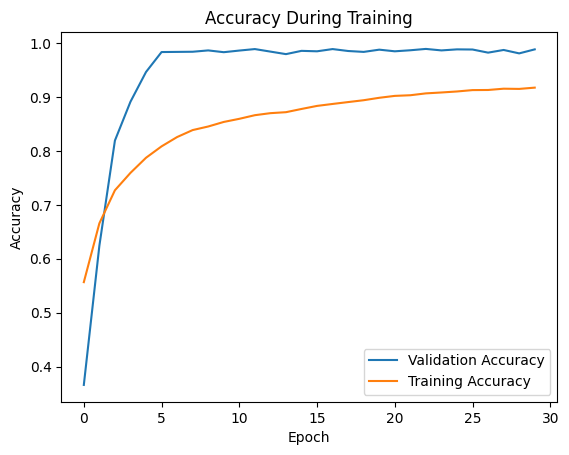

In [14]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.title('Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Validation Accuracy', 'Training Accuracy'])

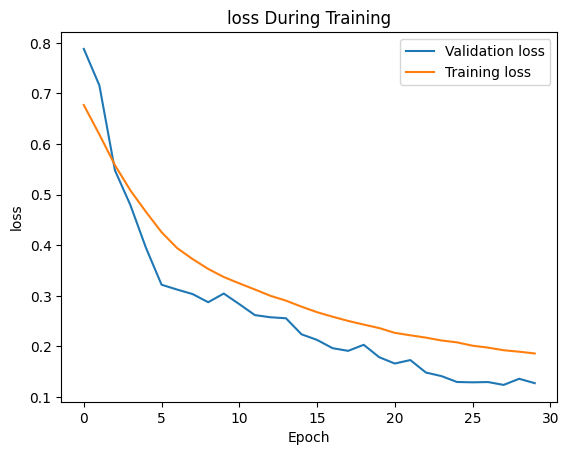

In [15]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])
plt.title('loss During Training')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(['Validation loss', 'Training loss'])

# DNN 튜닝

## 얼리스탑

In [33]:

model = Sequential()
model.add(Dense(128, activation='relu', input_dim = 48))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation = 'sigmoid'))
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-4)
model.summary()
model.compile(optimizer = opt, loss = 'binary_crossentropy', metrics =['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,018 (2.28 MB)

 Trainable params: 598,018 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(monitor='val_accuracy', mode='max', patience=3)

model.fit(X_train_balanced, y_train_balanced, verbose = 2, batch_size = 1024, epochs = 300, validation_split= 0.1, shuffle= True,  callbacks = [history, earlystop])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/300
32/32 - 6s - 190ms/step - accuracy: 0.5523 - loss: 0.6788 - val_accuracy: 0.2773 - val_loss: 0.8036
Epoch 2/300
32/32 - 3s - 86ms/step - accuracy: 0.6632 - loss: 0.6267 - val_accuracy: 0.5836 - val_loss: 0.7797
Epoch 3/300
32/32 - 3s - 90ms/step - accuracy: 0.7199 - loss: 0.5733 - val_accuracy: 0.7588 - val_loss: 0.6027
Epoch 4/300
32/32 - 3s - 99ms/step - accuracy: 0.7620 - loss: 0.5052 - val_accuracy: 0.9255 - val_loss: 0.4154
Epoch 5/300
32/32 - 3s - 79ms/step - accuracy: 0.7994 - loss: 0.4501 - val_accuracy: 0.9666 - val_loss: 0.3629
Epoch 6/300
32/32 - 5s - 141ms/step - accuracy: 0.8212 - loss: 0.4113 - val_accuracy: 0.9796 - val_loss: 0.3362
Epoch 7/300
32/32 - 5s - 156ms/step - accuracy: 0.8315 - loss: 0.3878 - val_accuracy: 0.9931 - val_loss: 0.3058
Epoch 8/300
32/32 - 5s - 148ms/step - accuracy: 0.8417 - loss: 0.3698 - val_accuracy: 0.9912 - val_loss: 0.3030
Epoch 9/300
32/32 - 5s - 158ms/step - accuracy: 0.8472 - loss: 0.3540 - val_accuracy: 0.9923 - val_loss: 0.3

In [35]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8759 - loss: 0.2116
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - accuracy: 0.8667 - loss: 0.2202


([0.2150893211364746, 0.9073194861412048],
 [0.20858734846115112, 0.8703588247299194])

In [38]:
from sklearn.metrics import f1_score
import numpy as np

# 저장된 베스트 가중치 로드
model.load_weights('weight_CNC_binary.weights.h5')

# 예측
y_pred = model.predict(X_test_scaled)

# y_test가 one-hot encoding 되어 있으면
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# F1 스코어
f1 = f1_score(y_true_labels, y_pred_labels)
print(f"F1 Score: {f1:.4f}")


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
F1 Score: 0.8993


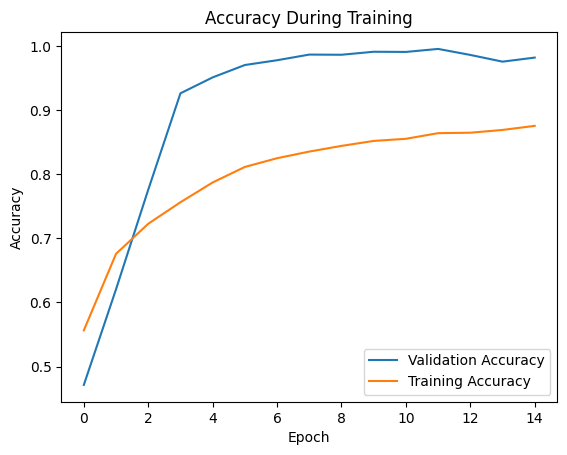

In [20]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.title('Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Validation Accuracy', 'Training Accuracy'])

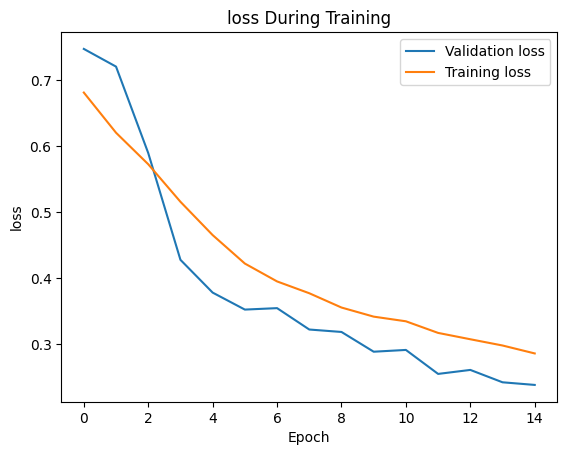

In [21]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])
plt.title('loss During Training')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(['Validation loss', 'Training loss'])

## 얼리스탑 + 학습률 1e-4 -> 1e-3으로 조정

In [39]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim = 48))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation = 'sigmoid'))
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-3)
model.summary()
model.compile(optimizer = opt, loss = 'binary_crossentropy', metrics =['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,018 (2.28 MB)

 Trainable params: 598,018 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(monitor='val_accuracy', mode='max', patience=3)

model.fit(X_train_balanced, y_train_balanced, verbose = 2, batch_size = 1024, epochs = 300, validation_split= 0.1, shuffle= True,  callbacks = [history, earlystop])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/300
32/32 - 6s - 201ms/step - accuracy: 0.7084 - loss: 0.5669 - val_accuracy: 0.9650 - val_loss: 0.4332
Epoch 2/300
32/32 - 3s - 84ms/step - accuracy: 0.8282 - loss: 0.3860 - val_accuracy: 0.9763 - val_loss: 0.3172
Epoch 3/300
32/32 - 3s - 81ms/step - accuracy: 0.8684 - loss: 0.3038 - val_accuracy: 0.9923 - val_loss: 0.2210
Epoch 4/300
32/32 - 4s - 115ms/step - accuracy: 0.8872 - loss: 0.2559 - val_accuracy: 0.9865 - val_loss: 0.1673
Epoch 5/300
32/32 - 3s - 96ms/step - accuracy: 0.9015 - loss: 0.2204 - val_accuracy: 0.9890 - val_loss: 0.1433
Epoch 6/300
32/32 - 2s - 65ms/step - accuracy: 0.9129 - loss: 0.1933 - val_accuracy: 0.9818 - val_loss: 0.1309


In [41]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9220 - loss: 0.1376
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9145 - loss: 0.1507


([0.13444308936595917, 0.938038170337677],
 [0.1426161676645279, 0.9184087514877319])

In [42]:
from sklearn.metrics import f1_score
import numpy as np

# 저장된 베스트 가중치 로드
model.load_weights('weight_CNC_binary.weights.h5')

# 예측
y_pred = model.predict(X_test_scaled)

# y_test가 one-hot encoding 되어 있으면
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# F1 스코어
f1 = f1_score(y_true_labels, y_pred_labels)
print(f"F1 Score: {f1:.4f}")


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
F1 Score: 0.9393


## 얼리스탑 + 드랍아웃 간소화 + 손실함수 변경 + 학습률 조정

In [43]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=48))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation = 'softmax'))
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-3)
model.summary()
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,362 (1.28 MB)

 Trainable params: 335,362 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(monitor='val_accuracy', mode='max', patience=3)

model.fit(X_train_balanced, y_train_balanced, verbose = 2, batch_size = 1024, epochs = 300, validation_split= 0.1, shuffle= True,  callbacks = [history, earlystop])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/300
32/32 - 4s - 135ms/step - accuracy: 0.7463 - loss: 0.5003 - val_accuracy: 0.9619 - val_loss: 0.3187
Epoch 2/300
32/32 - 2s - 59ms/step - accuracy: 0.8719 - loss: 0.2868 - val_accuracy: 0.9870 - val_loss: 0.1993
Epoch 3/300
32/32 - 2s - 51ms/step - accuracy: 0.9047 - loss: 0.2116 - val_accuracy: 0.9363 - val_loss: 0.2213
Epoch 4/300
32/32 - 2s - 66ms/step - accuracy: 0.9242 - loss: 0.1688 - val_accuracy: 0.9680 - val_loss: 0.1267
Epoch 5/300
32/32 - 2s - 54ms/step - accuracy: 0.9332 - loss: 0.1466 - val_accuracy: 0.9716 - val_loss: 0.0961


In [45]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9407 - loss: 0.1172
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9293 - loss: 0.1432


([0.1107574850320816, 0.9493817687034607],
 [0.13163641095161438, 0.9358814358711243])

In [46]:
from sklearn.metrics import f1_score
import numpy as np

# 저장된 베스트 가중치 로드
model.load_weights('weight_CNC_binary.weights.h5')

# 예측
y_pred = model.predict(X_test_scaled)

# y_test가 one-hot encoding 되어 있으면
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# F1 스코어
f1 = f1_score(y_true_labels, y_pred_labels)
print(f"F1 Score: {f1:.4f}")

201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
F1 Score: 0.9531


## 얼리스탑 + 드랍아웃 간소화 + 손실함수 변경 + 학습률 조정 + 배치 사이즈 조절

In [47]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=48))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation = 'softmax'))
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-3)
model.summary()
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,362 (1.28 MB)

 Trainable params: 335,362 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=48))
model.add(Dense(256, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))  # 0.3보다 살짝 낮춰도 됨
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax'))

In [53]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(monitor='val_accuracy', mode='max', patience=3)

model.fit(X_train_balanced, y_train_balanced, verbose = 2, batch_size = 512, epochs = 300, validation_split= 0.1, shuffle= True,  callbacks = [history, earlystop])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/300
64/64 - 2s - 25ms/step - accuracy: 0.7998 - loss: 0.4175 - val_accuracy: 0.9536 - val_loss: 0.2589
Epoch 2/300
64/64 - 1s - 9ms/step - accuracy: 0.9017 - loss: 0.2237 - val_accuracy: 0.9674 - val_loss: 0.1140
Epoch 3/300
64/64 - 1s - 9ms/step - accuracy: 0.9263 - loss: 0.1647 - val_accuracy: 0.9721 - val_loss: 0.1124
Epoch 4/300
64/64 - 1s - 14ms/step - accuracy: 0.9356 - loss: 0.1396 - val_accuracy: 0.9972 - val_loss: 0.0564
Epoch 5/300
64/64 - 1s - 13ms/step - accuracy: 0.9450 - loss: 0.1185 - val_accuracy: 0.9531 - val_loss: 0.1128
Epoch 6/300
64/64 - 1s - 17ms/step - accuracy: 0.9499 - loss: 0.1034 - val_accuracy: 0.9669 - val_loss: 0.0896
Epoch 7/300
64/64 - 1s - 15ms/step - accuracy: 0.9544 - loss: 0.0973 - val_accuracy: 0.9674 - val_loss: 0.0883


In [54]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.9669 - loss: 0.0711
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.9538 - loss: 0.0821


([0.07604556530714035, 0.9653897285461426],
 [0.07526146620512009, 0.959282398223877])

## 얼리스탑 + 드랍아웃 간소화 + 학습률 조정 + 배치 사이즈 조절 + 1차원

In [75]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=48))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # 이진 분류용
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-3)
model.summary()
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
history = History()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_115 (Dense)               │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,233 (1.28 MB)

 Trainable params: 335,233 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(monitor='val_accuracy', mode='max', patience=3)

model.fit(X_train_balanced, y_train_balanced, verbose = 2, batch_size = 512, epochs = 300, validation_split= 0.1, shuffle= True,  callbacks = [history, earlystop])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/300
64/64 - 2s - 26ms/step - accuracy: 0.8212 - loss: 0.3874 - val_accuracy: 0.9415 - val_loss: 0.2596
Epoch 2/300
64/64 - 1s - 11ms/step - accuracy: 0.9090 - loss: 0.2035 - val_accuracy: 0.9346 - val_loss: 0.1879
Epoch 3/300
64/64 - 1s - 12ms/step - accuracy: 0.9257 - loss: 0.1619 - val_accuracy: 0.9810 - val_loss: 0.0764
Epoch 4/300
64/64 - 1s - 12ms/step - accuracy: 0.9403 - loss: 0.1316 - val_accuracy: 0.9763 - val_loss: 0.0965
Epoch 5/300
64/64 - 1s - 14ms/step - accuracy: 0.9501 - loss: 0.1084 - val_accuracy: 0.9967 - val_loss: 0.0518
Epoch 6/300
64/64 - 1s - 14ms/step - accuracy: 0.9519 - loss: 0.1034 - val_accuracy: 0.9950 - val_loss: 0.0578
Epoch 7/300
64/64 - 1s - 13ms/step - accuracy: 0.9574 - loss: 0.0922 - val_accuracy: 0.9909 - val_loss: 0.0482
Epoch 8/300
64/64 - 1s - 12ms/step - accuracy: 0.9578 - loss: 0.0898 - val_accuracy: 0.9942 - val_loss: 0.0437


In [77]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.9528 - loss: 0.0862
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.9430 - loss: 0.1092


([0.0751522034406662, 0.963319718837738],
 [0.09874062240123749, 0.9486739635467529])

##

##  Dropout 위치 및 비율 조정 + Learning Rate Scheduler 사용

In [54]:

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=48))
model.add(Dense(256, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))  # 0.3보다 살짝 낮춰도 됨
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax'))

model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(1e-3)
model.summary()
model.compile(optimizer = opt, loss = 'binary_crossentropy', metrics =['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,362 (1.28 MB)

 Trainable params: 335,362 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
earlystop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

model.fit(X_train_balanced, y_train_balanced,
          batch_size=256,
          epochs=300,
          validation_split=0.1,
          shuffle=True,
          callbacks=[history,lr_scheduler, earlystop],
          verbose=2)


Epoch 1/300
128/128 - 2s - 19ms/step - accuracy: 0.8494 - loss: 0.3304 - val_accuracy: 0.9790 - val_loss: 0.1516 - learning_rate: 0.0010
Epoch 2/300
128/128 - 1s - 11ms/step - accuracy: 0.9283 - loss: 0.1609 - val_accuracy: 0.9509 - val_loss: 0.1226 - learning_rate: 0.0010
Epoch 3/300
128/128 - 1s - 9ms/step - accuracy: 0.9430 - loss: 0.1275 - val_accuracy: 0.9845 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 4/300
128/128 - 1s - 10ms/step - accuracy: 0.9472 - loss: 0.1150 - val_accuracy: 0.9633 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 5/300
128/128 - 1s - 9ms/step - accuracy: 0.9572 - loss: 0.0950 - val_accuracy: 0.9879 - val_loss: 0.0690 - learning_rate: 0.0010
Epoch 6/300
128/128 - 1s - 9ms/step - accuracy: 0.9603 - loss: 0.0827 - val_accuracy: 0.9699 - val_loss: 0.0695 - learning_rate: 0.0010
Epoch 7/300
128/128 - 1s - 11ms/step - accuracy: 0.9620 - loss: 0.0788 - val_accuracy: 0.9912 - val_loss: 0.0440 - learning_rate: 0.0010
Epoch 8/300
128/128 - 2s - 16ms/step - accur

In [56]:
loss_and_metrics = model.evaluate(X_train_balanced, y_train_balanced, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test_scaled, y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.9774 - loss: 0.0435
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.9650 - loss: 0.0636


([0.04360629618167877, 0.9777268767356873],
 [0.06221304461359978, 0.9669266939163208])

In [57]:
from sklearn.metrics import f1_score
import numpy as np

# 저장된 베스트 가중치 로드
model.load_weights('weight_CNC_binary.weights.h5')

# 예측
y_pred = model.predict(X_test_scaled)

# y_test가 one-hot encoding 되어 있으면
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# F1 스코어
f1 = f1_score(y_true_labels, y_pred_labels)
print(f"F1 Score: {f1:.4f}")

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step
F1 Score: 0.9531


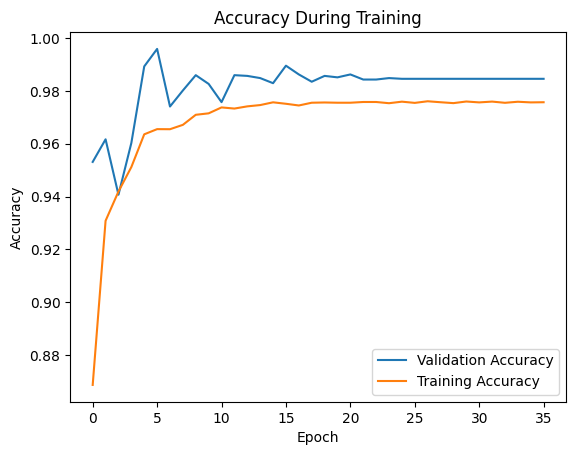

In [32]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.title('Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Validation Accuracy', 'Training Accuracy'])

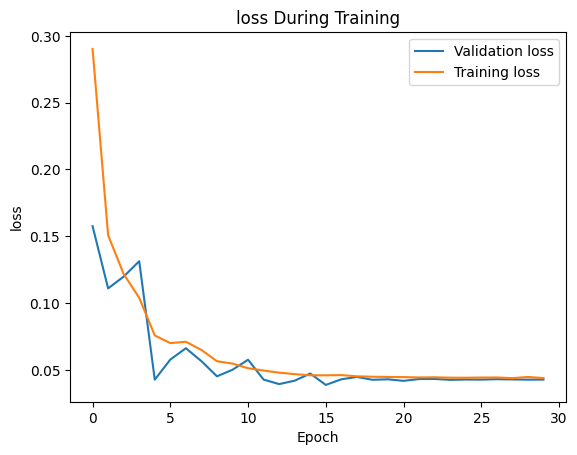

In [28]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])
plt.title('loss During Training')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(['Validation loss', 'Training loss'])